In [1]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"]= os.getenv("GEMINI_API_KEY")
os.environ["TAVILY_API_KEY"]= os.getenv("TAVILY_API_KEY")

model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=os.environ["GEMINI_API_KEY"],
)

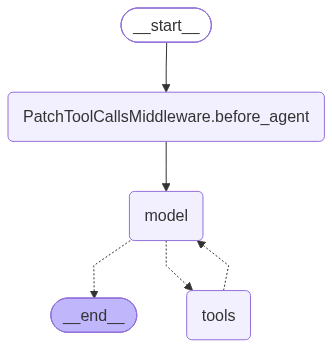

In [2]:
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient
client=TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_research(query:str,max_results:int=5,topic:Literal["general","news","finance"]="general",include_raw_content:bool=True):
    """Runn a web search"""
    return client.search(query,max_results=max_results,include_raw_content=include_raw_content,topic=topic)

research_agent={
    "name":"research-agent",
    "description":"Used to research more in depth questions",
    "system_prompt":"You are a great researcher",
    "tools":[internet_research],
    "model":"groq:qwen/qwen3-27b"} #if agent didnt work this would work 

subagents=[research_agent]

agent=create_deep_agent(
    model=model,
    subagents=subagents
    )
agent


In [4]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "Research about llm gateways and plugins and return the output be briefff"}],
        # "files": skills_files,
    },
    config={"configurable": {"thread_id": "skillsss-demo-2"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research about llm gateways and plugins and return the output be briefff
================================== Ai Message ==================================

[]
Tool Calls:
  ls (call_560156)
 Call ID: call_560156
  Args:
    path: .
================================= Tool Message =================================
Name: ls

No files found
================================== Ai Message ==================================

[{'type': 'text', 'text': '### **1. LLM Gateways**\nAn API management layer (reverse proxy) between client applications and multiple LLM providers.\n\n* **Core Functions:**\n  * **Unified API:** Access 100+ LLMs (OpenAI, Anthropic, Llama, etc.) via a single standardized endpoint.\n  * **Routing & Fallbacks:** Dynamic routing, load balancing, and failover (e.g., fallback if a provider drops or rate-limits).\n  * **Cost & Rate Management:** Semantic caching, token budgeting, rate limiting, and co

# STROUTPUT WITH subagent

In [ ]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task."""
    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of source URLs")

research_subagent = {
    "name": "researcher",
    "description": "Researches topics and returns structured findings",
    "system_prompt": "Research the given topic thoroughly. Return your findings.",
    "tools": [internet_research],
    "response_format": ResearchFindings,
}

agent = create_deep_agent(
    model=model,
    subagents=[research_subagent],
)

result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Research recent advances in quantum computing"}]}
)

In [ ]:
for m in result["messages"]:
    m.pretty_print()